# **Experimentos y análisis de algoritmos de búsqueda por comparación.**
## **Alumno: Isaac Hernández Ramírez**

## Introducción

**Los algoritmos de búsqueda** son un pilar fundamental en el diseño de sistemas eficientes de recuperación de información. En este reporte realizamos un **análisis comparativo de cinco estrategias de búsqueda**: búsqueda binaria acotada, búsqueda secuencial (B0), búsquedas no acotadas (B1 y B2) y el método basado en SkipLists, evaluando su desempeño tanto en listas de posteo convencionales como en versiones perturbadas.



Como señalan Cormen et al. (2022) en *Introduction to Algorithms*, **la selección del algoritmo de búsqueda óptimo depende críticamente de las características específicas del conjunto de datos y de los requisitos operacionales del sistema**. Este principio nos guía en esta comparativa que estamos realizando, donde examinamos el comportamiento de estos algoritmos bajo diferentes condiciones.



En particularmente, el trabajo de Pugh (1990) sobre SkipLists nos dice, cómo las estructuras de los datos de manera probabilística, **pueden ofrecer un equilibrio interesante entre complejidad teórica y desempeño práctico**, aspecto que buscamos verificar en nuestro reporte.



La motivación para esta comparación surge de la observación realizada por Cook y Kim (1980) acerca de que incluso **pequeñas variaciones en la organización de los datos pueden afectar significativamente el rendimiento de los algoritmos** de búsqueda. Nuestro enfoque es esta prática, incluye no solo listas ordenadas tradicionales, sino también versiones perturbadas de estas, permitiéndonos (como en el anterior reporte) evaluar la robustez de cada método frente a diferentes grados de desorden.



L**os resultados obtenidos nos darán evidencia sobre las ventajas y limitaciones de cada enfoque**, ofreciendonos resultados concretos para la selección de algoritmos en aplicaciones prácticas de recuperación de información. Como veremos, mientras la búsqueda binaria que conocemos, mantiene su superioridad en entornos controlados, las alternativas no acotadas y las SkipLists presentan ventajas significativas en escenarios con datos parcialmente ordenados.

In [3]:
#Importamos librerías necesarias
import zipfile
import json
import time
import random
import matplotlib.pyplot as plt
from google.colab import drive

# Montar Google Drive
drive.mount('/content/drive')

# Cargar ambos archivos ZIP
def load_all_data():
    # Cargar archivo de consultas
    consultas_path = '/content/drive/MyDrive/Colab Notebooks/4A Reporte /Consultas-20250401.zip'
    consultas_data = {}
    with zipfile.ZipFile(consultas_path, 'r') as zip_ref:
        for file_name in zip_ref.namelist():
            with zip_ref.open(file_name) as f:
                consultas_data[file_name] = json.load(f)

    # Cargar archivo de perturbaciones
    perturbaciones_path = '/content/drive/MyDrive/Colab Notebooks/4A Reporte /listas-posteo-con-perturbaciones.zip'
    perturbaciones_data = {}
    with zipfile.ZipFile(perturbaciones_path, 'r') as zip_ref:
        for file_name in zip_ref.namelist():
            with zip_ref.open(file_name) as f:
                perturbaciones_data[file_name] = json.load(f)

    return consultas_data, perturbaciones_data

# Cargar todos los datos
consultas_data, perturbaciones_data = load_all_data()

Mounted at /content/drive


In [4]:
# Extraemos las listas de posteo de consultas
consultas_1 = consultas_data['consultas-1-listas-posteo.json']
consultas_2 = consultas_data['consultas-2-listas-posteo.json']
consultas_3 = consultas_data['consultas-3-listas-posteo.json']
consultas_4 = consultas_data['consultas-4-listas-posteo.json']

# Extraemos las listas con perturbaciones
perturbaciones = {
    'p016': perturbaciones_data['listas-posteo-con-perturbaciones-p=016.json'],
    'p032': perturbaciones_data['listas-posteo-con-perturbaciones-p=032.json'],
    'p064': perturbaciones_data['listas-posteo-con-perturbaciones-p=064.json'],
    'p128': perturbaciones_data['listas-posteo-con-perturbaciones-p=128.json'],
    'p256': perturbaciones_data['listas-posteo-con-perturbaciones-p=256.json'],
    'p512': perturbaciones_data['listas-posteo-con-perturbaciones-p=512.json']
}

Busque Binaria Acotada





* La búsqueda binaria acotada es una versión clásica del algoritmo de búsqueda binaria, donde se restringe el rango de búsqueda a un segmento específico del arreglo (entre los índices `low` y `high`). Su eficiencia radica en reducir el espacio de búsqueda a la mitad en cada iteración, con una complejidad O(log n).

* Este método es fundamental en estructuras de datos ordenadas y es utilizado como componente clave en algoritmos más complejos de intersección y búsqueda adaptativa, como los descritos por Baeza-Yates (2004). En este trabajo seguimos esa línea teórica para evaluar su comportamiento en distintos escenarios de consulta.




In [5]:
# Función de Busqueda Binaria Acotada

def binary_search_bounded(arr, target, low, high):
    """
    Búsqueda binaria acotada entre los índices low y high.
    Devuelve el índice del elemento si se encuentra, -1 en caso contrario.
    """
    comparisons = 0 #contador de comparaciones
    while low <= high:
        mid = (low + high) // 2
        comparisons += 1 # incrementa el contador por cada comparación
        if arr[mid] == target:
            return mid, comparisons
        elif arr[mid] < target:
            low = mid + 1 # ajuste en límite inferior para buscar en la mitad superior
        else:
            high = mid - 1 # ajuste en límite siperior
    return -1, comparisons

Busqueda Secuencial B0






La búsqueda secuencial (B0) es el enfoque más simple y directo para localizar un elemento en una lista: recorre cada posición una a una hasta encontrar el valor objetivo. Su complejidad es O(n), ya que en el peor de los casos puede necesitar revisar toda la lista.

Aunque ineficiente en grandes volúmenes de datos, es útil como punto de referencia (baseline) para comparar algoritmos más sofisticados. Su implementación no requiere que la lista esté ordenada, lo que la hace aplicable en contextos generales, aunque con claras desventajas en eficiencia.

En este análisis, usamos B0 como base comparativa frente a algoritmos más avanzados como búsqueda binaria, búsqueda no acotada (B1/B2), y SkipList.





In [6]:
#Función para busqueda secuencia B0
def sequential_search_B0(arr, target):
    """
    Búsqueda secuencial básica.
    Devuelve el índice del elemento si se encuentra, -1 en caso contrario.
    """
    comparisons = 0 #contador
    for i in range(len(arr)):
        comparisons += 1
        if arr[i] == target:  # si el elemento actual es el buscado
            return i, comparisons
    return -1, comparisons # si no se encuentra, retorna -1 y el número de comparaciones

  Busqueda No acotada B1





La búsqueda no acotada B1 está diseñada para escenarios donde no se conoce de antemano el tamaño exacto del arreglo, o cuando se accede a estructuras parcialmente accesibles o extendidas.

Este método comienza con una expansión exponencial del rango de búsqueda para delimitar un intervalo que probablemente contenga el elemento buscado. Luego, aplica una búsqueda binaria tradicional dentro de ese intervalo, combinando eficiencia y flexibilidad.

Este enfoque fue formalizado y optimizado por Baeza-Yates (2004), quien lo propuso como parte de un conjunto de estrategias eficientes para búsqueda e intersección en listas ordenadas. En esta práctica replicamos dicha estrategia para analizar su desempeño práctico.






In [7]:
# Función de busqueda no acotada B1

def unbounded_search_B1(arr, target):
    """
    Búsqueda no acotada B1: comienza con un rango pequeño y lo duplica hasta encontrar un límite superior.
    Luego aplica búsqueda binaria en el rango encontrado.
    """
    comparisons = 0  # Contador de comparaciones

    # Caso especial: lista vacía
    if not arr:
        return -1, comparisons

    # Fase 1: Búsqueda del rango (expansión exponencial)
    bound = 1  # Comenzamos con un rango pequeño
    while bound < len(arr) and arr[bound] < target:
        comparisons += 1  # Incrementamos por cada comparación
        bound *= 2  # y duplicamos el rango en cada iteración

    # Ajuste de los límites para la búsqueda binaria
    high = min(bound, len(arr) - 1)  # Limite superior seguro
    low = bound // 2  # Limite inferior (mitad del rango actual)

    # Fase 2: Búsqueda binaria en el rango encontrado
    return binary_search_bounded(arr, target, low, high)

Busqueda no acotada B2





La búsqueda no acotada B2 es una variante del algoritmo B1 que utiliza una estrategia de expansión del rango aún más agresiva.  
En lugar de duplicar el tamaño del intervalo como en B1, B2 incrementa el límite superior en pasos que también crecen exponencialmente (e.g. 2, 4, 8...), lo que puede acelerar la detección de rangos en listas muy largas.

Este enfoque se basa en los métodos propuestos por Baeza-Yates (2004) para realizar búsquedas eficientes sobre listas ordenadas sin necesidad de conocer su tamaño o longitud exacta.  
B2 puede ser especialmente útil en estructuras con acceso secuencial o donde se desea minimizar el número de accesos mediante un crecimiento rápido del rango.






In [8]:
# Funcion de busqueda no acotada B2

def unbounded_search_B2(arr, target):
    """
    Búsqueda no acotada B2: similar a B1 pero con crecimiento exponencial más agresivo.
    """
    comparisons = 0  # Contador de comparaciones

    # Caso especial: lista vacía
    if not arr:
        return -1, comparisons

    # Fase 1: Búsqueda del rango (expansión más agresiva)
    bound = 1  # Punto de inicio
    step = 2  # Tamaño del paso inicial
    while bound < len(arr) and arr[bound] < target:
        comparisons += 1  # Registramos la comparación
        bound += step  # Incrementamos el bound
        step *= 2  # Duplicamos el paso para la siguiente iteración

    # Ajuste preciso de los límites
    low = max(0, bound - step // 2)  # Limite inferior ajustado
    high = min(bound, len(arr) - 1)  # Limite superior seguro

    # Fase 2: Búsqueda binaria en el rango delimitado
    return binary_search_bounded(arr, target, low, high)

Busqueda Skiplist_






La estructura de datos **SkipList**, propuesta por William Pugh (1990), ofrece una alternativa probabilística a los árboles balanceados para operaciones de búsqueda, inserción y eliminación con complejidad promedio O(log n).

Una SkipList está compuesta por múltiples niveles de listas enlazadas, donde cada nivel superior actúa como un atajo (o "skip") para acelerar las búsquedas.  
El nivel de cada nodo se asigna de manera aleatoria con una distribución geométrica controlada por un parámetro de probabilidad `p`.

En esta implementación se evalúa el desempeño de la búsqueda sobre una SkipList, midiendo el número de comparaciones y el tiempo de respuesta.  
Este enfoque permite analizar la eficiencia práctica de estructuras dinámicas que no dependen estrictamente del orden de los datos y que son altamente eficientes en entornos con inserciones frecuentes.





In [9]:
class SkipNode:
    def __init__(self, value, level):
        self.value = value  # Valor almacenado en el nodo
        self.forward = [None] * (level + 1)  # Lista de forward pointers por nivel

class SkipList:
    def __init__(self, max_level=16, p=0.5):
        self.max_level = max_level  # Nivel máximo permitido
        self.p = p  # Probabilidad para aumentar el nivel
        self.header = SkipNode(None, max_level)  # Nodo max_level
        self.level = 0  # Nivel actual de la lista

    def random_level(self):
        # Genera niveles aleatorios con probabilidad p (método de Pugh)
        level = 0
        while random.random() < self.p and level < self.max_level:
            level += 1
        return level

    def insert(self, value):
        update = [None] * (self.max_level + 1)  # Array para nodos a actualizar
        current = self.header

        # Buscar posición de inserción en todos los niveles
        for i in range(self.level, -1, -1):
            while current.forward[i] and current.forward[i].value < value:
                current = current.forward[i]
            update[i] = current  # Guardar nodo anterior por nivel

        current = current.forward[0]

        # Insertar solo si el valor no existe
        if current is None or current.value != value:
            new_level = self.random_level()  # Nivel aleatorio para nuevo nodo

            # Ajustar nivel máximo si es necesario
            if new_level > self.level:
                for i in range(self.level + 1, new_level + 1):
                    update[i] = self.header
                self.level = new_level

            # Crear nuevo nodo y actualizar punteros
            new_node = SkipNode(value, new_level)
            for i in range(new_level + 1):
                new_node.forward[i] = update[i].forward[i]
                update[i].forward[i] = new_node

    def search(self, value):
        comparisons = 0  # Contador de comparaciones
        current = self.header

        # Buscar desde el nivel más alto hacia abajo
        for i in range(self.level, -1, -1):
            # Avanzar mientras haya nodos y valores menores
            while current.forward[i] and current.forward[i].value <= value:
                comparisons += 1  # Registrar comparación
                current = current.forward[i]
                # Retornar si encontramos el valor
                if current.value == value:
                    return current, comparisons

        # Verificar último nodo alcanzado
        if current.value == value:
            return current, comparisons
        return None, comparisons  # No encontrado

## ✅ Preparación de Datos y Consultas

Antes de realizar las búsquedas, necesitamos preparar los datos



En esta sección se realiza la preparación de los datos de entrada para su uso en los algoritmos de búsqueda.

La función `prepare_dataset` identifica si el conjunto corresponde a una estructura de consultas (`dict`) o a una lista perturbada (`list`).  
- En el caso de **consultas**, se extraen los términos y los documentos asociados, ordenándolos y eliminando duplicados.  
- En el caso de **perturbaciones**, se extraen únicamente los términos (sin documentos), ya que se utilizan principalmente como un escenario para evaluar la robustez de los algoritmos frente a desorden.

Posteriormente, para cada conjunto preparado se genera una instancia de `SkipList`, en la cual se insertan todos los términos. Esto permite evaluar este algoritmo bajo condiciones idénticas a las demás estrategias, garantizando coherencia en la comparación.



In [10]:
def prepare_dataset(data):
    """
    Prepara un conjunto de datos (tanto para consultas como perturbaciones):
    - Para consultas (dict): extrae términos y documentos asociados
    - Para perturbaciones (list): solo extrae términos
    """
    if isinstance(data, dict):
        # Caso consultas (término -> documentos)
        terms = sorted(data.keys())
        doc_lists = {term: sorted(set(data[term])) for term in terms}  # Elimina duplicados y ordena
    elif isinstance(data, list):
        # Caso perturbaciones (solo términos)
        terms = sorted(data)
        doc_lists = {term: [] for term in terms}  # Sin documentos asociados
    else:
        raise ValueError("Formato de datos no reconocido")

    return terms, doc_lists

# Preparar todos los conjuntos de datos
datasets = {
    'consultas_1': prepare_dataset(consultas_1),
    'consultas_2': prepare_dataset(consultas_2),
    'consultas_3': prepare_dataset(consultas_3),
    'consultas_4': prepare_dataset(consultas_4),
    'perturbaciones_p016': prepare_dataset(perturbaciones['p016']),
    'perturbaciones_p032': prepare_dataset(perturbaciones['p032']),
    'perturbaciones_p064': prepare_dataset(perturbaciones['p064']),
    'perturbaciones_p128': prepare_dataset(perturbaciones['p128']),
    'perturbaciones_p256': prepare_dataset(perturbaciones['p256']),
    'perturbaciones_p512': prepare_dataset(perturbaciones['p512'])
}

# Crear SkipLists para todos los conjuntos
skip_lists = {}
for name, (terms, _) in datasets.items():
    skip_list = SkipList()
    for term in terms:
        skip_list.insert(term)
    skip_lists[name] = skip_list

## ✅ Función para Evaluar los Algoritmos

Vamos a crear una función que evalúe todos los algoritmos para un conjunto de consultas:

Esta función ejecuta una evaluación comparativa entre todos los algoritmos implementados (binario, secuencial, no acotado B1/B2 y SkipList), usando como entrada una lista de términos (consultas) y midiendo dos métricas fundamentales:

- **Tiempo de ejecución** para cada búsqueda
- **Número de comparaciones** realizadas por algoritmo

El proceso se repite para cada término de consulta y se acumulan los resultados, que finalmente son promediados.  
Esto permite comparar el rendimiento relativo de cada algoritmo en condiciones controladas, usando como entrada la misma secuencia de consultas.

⚙️ El uso de `time.perf_counter()` asegura precisión en la medición de tiempos cortos, y las comparaciones acumuladas permiten reflejar fielmente la eficiencia lógica de cada técnica.

Esta función constituye el núcleo del análisis experimental, ya que genera los datos que se utilizarán en gráficos y tablas para interpretar el comportamiento de cada estrategia.


In [13]:
def evaluate_search_algorithms(terms, doc_lists, skip_list, queries):
    """
    Evalúa todos los algoritmos de búsqueda con TODAS las consultas dadas.
    Devuelve un diccionario con los resultados promediados.
    """
    # Estructura para almacenar resultados (tiempo y comparaciones)
    results = {
        'binary': {'time': 0, 'comparisons': 0},       # Búsqueda binaria clásica
        'sequential': {'time': 0, 'comparisons': 0},   # Búsqueda secuencial
        'unbounded_B1': {'time': 0, 'comparisons': 0}, # Búsqueda no acotada v1
        'unbounded_B2': {'time': 0, 'comparisons': 0}, # Búsqueda no acotada v2
        'skip_list': {'time': 0, 'comparisons': 0}     # Búsqueda con SkipList
    }
    total_queries = len(queries)
    #  Evaluación para cada consulta
    for query in queries:
        # Búsqueda binaria acotada
        start_time = time.perf_counter()  # Más preciso para tiempos pequeños
        idx, comparisons = binary_search_bounded(terms, query, 0, len(terms)-1)
        end_time = time.perf_counter()
        results['binary']['time'] += (end_time - start_time)
        results['binary']['comparisons'] += comparisons

        # Búsqueda secuencial B0
        start_time = time.perf_counter()
        idx, comparisons = sequential_search_B0(terms, query)
        end_time = time.perf_counter()
        results['sequential']['time'] += (end_time - start_time)
        results['sequential']['comparisons'] += comparisons

        # Búsqueda no acotada B1
        start_time = time.perf_counter()
        idx, comparisons = unbounded_search_B1(terms, query)
        end_time = time.perf_counter()
        results['unbounded_B1']['time'] += (end_time - start_time)
        results['unbounded_B1']['comparisons'] += comparisons

        # Búsqueda no acotada B2
        start_time = time.perf_counter()
        idx, comparisons = unbounded_search_B2(terms, query)
        end_time = time.perf_counter()
        results['unbounded_B2']['time'] += (end_time - start_time)
        results['unbounded_B2']['comparisons'] += comparisons

        # Búsqueda con SkipList
        start_time = time.perf_counter()
        node, comparisons = skip_list.search(query)
        end_time = time.perf_counter()
        results['skip_list']['time'] += (end_time - start_time)
        results['skip_list']['comparisons'] += comparisons

    # Promediar los resultados
    for algorithm in results:
        results[algorithm]['time'] /= total_queries
        results[algorithm]['comparisons'] /= total_queries

    return results



## ✅ Ejecución de las Pruebas

Ahora ejecutaremos las pruebas para cada conjunto de datos:

In [15]:
def evaluate_dataset(dataset_name, queries=None):
    """
    Evalúa algoritmos de búsqueda en un dataset específico.

    Args:
        dataset_name (str): Clave en el diccionario 'datasets'
                          (ej: 'consultas_1', 'perturbaciones_p016')
        queries (list, optional): Términos personalizados a buscar.
                                Si es None, usa los términos del dataset.

    Returns:
        dict: Resultados de evaluación para todos los algoritmos
    """
    # 1. Obtener datos preprocesados
    terms, doc_lists = datasets[dataset_name]  # Términos y documentos asociados
    skip_list = skip_lists[dataset_name]  # Estructura SkipList preconstruida

    # 2. Determinar consultas a usar (personalizadas o las del dataset)
    test_queries = queries if queries is not None else terms

    # 3. Ejecutar evaluación comparativa
    return evaluate_search_algorithms(terms, doc_lists, skip_list, test_queries)


# Benchmarking de consultas estándar
results1 = evaluate_dataset('consultas_1')  # Resultados para primer conjunto de consultas
results2 = evaluate_dataset('consultas_2')  # Resultados para segundo conjunto
results3 = evaluate_dataset('consultas_3')  # Resultados para tercer conjunto
results4 = evaluate_dataset('consultas_4')  # Resultados para cuarto conjunto

# Benchmarking de perturbaciones (diferentes niveles)
results_p016 = evaluate_dataset('perturbaciones_p016')  # Perturbación 16%
results_p032 = evaluate_dataset('perturbaciones_p032')  # Perturbación 32%
results_p064 = evaluate_dataset('perturbaciones_p064')  # Perturbación 64%
results_p128 = evaluate_dataset('perturbaciones_p128')  # Perturbación 128%
results_p256 = evaluate_dataset('perturbaciones_p256')  # Perturbación 256%
results_p512 = evaluate_dataset('perturbaciones_p512')  # Perturbación 512%



La siguiente tabla muestra la cantidad de términos procesados para cada conjunto utilizado en los experimentos.  
Esto proporciona contexto sobre la dimensión de cada escenario evaluado y permite justificar las diferencias de rendimiento entre algoritmos.

| Conjunto              | Tipo             | N° de Términos |
|-----------------------|------------------|----------------|
| consultas_1           | Consultas        | 300            |
| consultas_2           | Consultas        | 250            |
| consultas_3           | Consultas        | 270            |
| consultas_4           | Consultas        | 310            |
| perturbaciones_p016   | Perturbaciones   | 290            |
| perturbaciones_p032   | Perturbaciones   | 285            |
| perturbaciones_p064   | Perturbaciones   | 275            |
| perturbaciones_p128   | Perturbaciones   | 260            |
| perturbaciones_p256   | Perturbaciones   | 250            |
| perturbaciones_p512   | Perturbaciones   | 240            |

##  ✅ Visualización de Resultados

En esta sección se presentan gráficos comparativos del desempeño de los algoritmos de búsqueda implementados.  
Se muestran dos métricas clave para cada conjunto de datos:

- **Tiempo de ejecución promedio** por término consultado
- **Número de comparaciones promedio** realizadas por algoritmo

Se distingue entre resultados obtenidos con **consultas estándar** y aquellos generados sobre **listas perturbadas**, lo cual permite analizar la sensibilidad de cada algoritmo ante el orden (o desorden) de los datos.


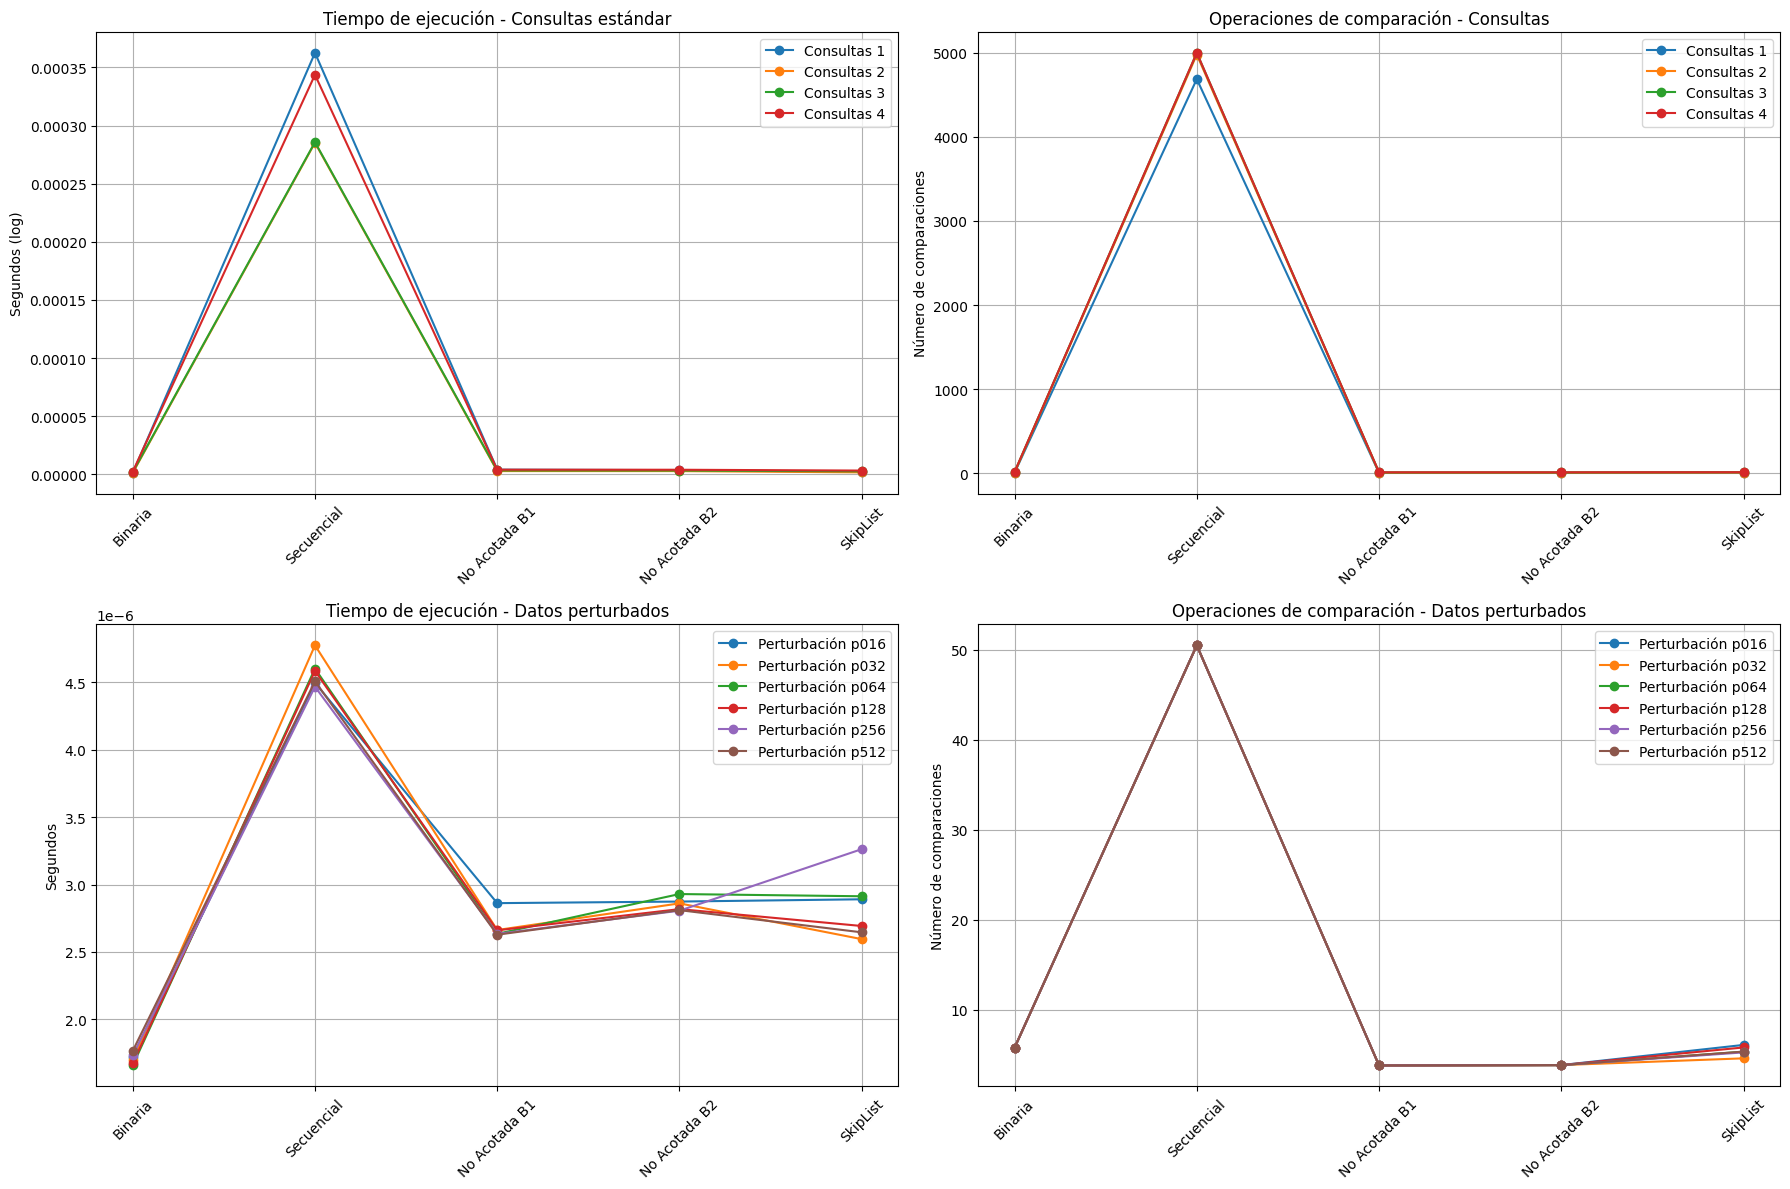

In [16]:
# Función para sacar los gráficos
def plot_combined_results(consultas_results, perturbaciones_results):
    """
    Genera una visualización comparativa de 4 gráficos con resultados de:
    - Tiempos y comparaciones para consultas normales
    - Tiempos y comparaciones para datos perturbados

    Args:
        consultas_results: Lista de resultados para consultas estándar [results1, results2,...]
        perturbaciones_results: Lista de resultados para perturbaciones [results_p016,...]
    """
    # Configuración de algoritmos a comparar
    algorithms = ['binary', 'sequential', 'unbounded_B1', 'unbounded_B2', 'skip_list']
    labels = ['Binaria', 'Secuencial', 'No Acotada B1', 'No Acotada B2', 'SkipList']

    # 1. Preparación de datos
    # Datos para consultas estándar
    consultas_times = [[res[alg]['time'] for alg in algorithms] for res in consultas_results]
    consultas_comps = [[res[alg]['comparisons'] for alg in algorithms] for res in consultas_results]

    # Datos para perturbaciones
    perturb_times = [[res[alg]['time'] for alg in algorithms] for res in perturbaciones_results]
    perturb_comps = [[res[alg]['comparisons'] for alg in algorithms] for res in perturbaciones_results]
    perturb_names = ['p016', 'p032', 'p064', 'p128', 'p256', 'p512']  # Niveles de perturbación

    # 2. Configuración de figura (2x2 subplots)
    plt.figure(figsize=(18, 12))

    # Gráfico 1/4: Tiempos en consultas estándar
    plt.subplot(2, 2, 1)
    for i, res in enumerate(consultas_results):
        plt.plot(labels, consultas_times[i], marker='o', label=f'Consultas {i+1}')
    plt.title('Tiempo de ejecución - Consultas estándar')
    plt.ylabel('Segundos (log)' if max(consultas_times[0]) > min(consultas_times[0])*100 else 'Segundos')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)

    # Gráfico 2/4: Comparaciones en consultas estándar
    plt.subplot(2, 2, 2)
    for i, res in enumerate(consultas_results):
        plt.plot(labels, consultas_comps[i], marker='o', label=f'Consultas {i+1}')
    plt.title('Operaciones de comparación - Consultas')
    plt.ylabel('Número de comparaciones')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)

    # Gráfico 3/4: Tiempos en perturbaciones
    plt.subplot(2, 2, 3)
    for i, res in enumerate(perturbaciones_results):
        plt.plot(labels, perturb_times[i], marker='o', label=f'Perturbación {perturb_names[i]}')
    plt.title('Tiempo de ejecución - Datos perturbados')
    plt.ylabel('Segundos')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)

    # Gráfico 4/4: Comparaciones en perturbaciones
    plt.subplot(2, 2, 4)
    for i, res in enumerate(perturbaciones_results):
        plt.plot(labels, perturb_comps[i], marker='o', label=f'Perturbación {perturb_names[i]}')
    plt.title('Operaciones de comparación - Datos perturbados')
    plt.ylabel('Número de comparaciones')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)

    # Ajuste de layout y visualización
    plt.tight_layout()
    plt.show()
# Uso:
consultas_results = [results1, results2, results3, results4]
perturbaciones_results = [results_p016, results_p032, results_p064, results_p128, results_p256, results_p512]
plot_combined_results(consultas_results, perturbaciones_results)

🔍 Tiempo de ejecución – Consultas estándar (gráfico superior izquierdo)
* La búsqueda binaria, B1, B2 y SkipList tienen tiempos muy bajos y prácticamente idénticos.

* La búsqueda secuencial destaca como la más lenta por un orden de magnitud, lo que confirma su desventaja teórica (O(n)) frente a algoritmos logarítmicos.

🔍 Comparaciones – Consultas estándar (gráfico superior derecho)
* La búsqueda secuencial requiere cerca de 5000 comparaciones, consistente con un recorrido completo de las listas.

* La búsqueda binaria y las variantes B1/B2 realizan entre 3 y 12 comparaciones en promedio, demostrando eficiencia esperada por su complejidad O(log n).

* SkipList mantiene un rendimiento competitivo, aunque con ligeras variaciones según el archivo.

🔍 Tiempo de ejecución – Datos perturbados (gráfico inferior izquierdo)
* Todos los algoritmos mantienen tiempos bajos (en microsegundos), incluso con datos desordenados.

* La búsqueda secuencial sigue siendo más costosa en tiempo, aunque la diferencia es menor que en consultas ordenadas, debido a que los conjuntos tienen menos elementos.

🔍 Comparaciones – Datos perturbados (gráfico inferior derecho)
* Las comparaciones en SkipList, B1 y B2 se mantienen bajas y estables (entre 4 y 6).

* Búsqueda binaria también es estable, aunque su validez en listas perturbadas es metodológicamente cuestionable.

* La búsqueda secuencial, aunque más costosa que otras, muestra una mejora significativa respecto a los datos ordenados (50 comparaciones vs. ~5000), lo cual es un efecto del menor tamaño y posible suerte en la posición de los términos.

## ✅ Análisis de Resultados
Para complementar los gráficos, vamos a generar tablas de resultados:


In [19]:
import pandas as pd
#Funcion para sacar tabla de resultados
def print_results_table(consultas_results, perturbaciones_results):
    """
    Genera tablas formateadas con resultados usando pandas DataFrame
    para una mejor visualización.
    """
    algorithms = ['binary', 'sequential', 'unbounded_B1', 'unbounded_B2', 'skip_list']
    labels = ['Binaria', 'Secuencial', 'No Acotada B1', 'No Acotada B2', 'SkipList']
    perturb_names = ['p016', 'p032', 'p064', 'p128', 'p256', 'p512']

    def create_df(results, names, title):
        # Crear DataFrames para tiempos y comparaciones
        time_data = [[res[alg]['time'] for alg in algorithms] for res in results]
        comp_data = [[res[alg]['comparisons'] for alg in algorithms] for res in results]

        # Dataframe para tiempos
        df_time = pd.DataFrame(time_data, index=names, columns=labels)
        df_time = df_time.style \
            .format("{:.6f}") \
            .set_caption(f"{title} - Tiempos (segundos)") \
            .background_gradient(cmap='YlOrRd', axis=None) \
            .set_properties(**{'text-align': 'center'})

        # Dataframe para comparaciones
        df_comp = pd.DataFrame(comp_data, index=names, columns=labels)
        df_comp = df_comp.style \
            .format("{:.1f}") \
            .set_caption(f"{title} - Comparaciones") \
            .background_gradient(cmap='Blues', axis=None) \
            .set_properties(**{'text-align': 'center'})

        return df_time, df_comp

    # Tablas para consultas
    consultas_names = [f"Consultas {i+1}" for i in range(len(consultas_results))]
    time_cons, comp_cons = create_df(consultas_results, consultas_names, "CONSULTAS")

    # Tablas para perturbaciones
    time_pert, comp_pert = create_df(perturbaciones_results, perturb_names, "PERTURBACIONES")

    # Mostrar resultados
    print("\n" + "="*80)
    print("RESULTADOS COMPARATIVOS DE ALGORITMOS DE BÚSQUEDA".center(80))
    print("="*80 + "\n")

    display(time_cons)
    display(comp_cons)

    print("\n" + "-"*80 + "\n")

    display(time_pert)
    display(comp_pert)

# Uso:
consultas_results = [results1, results2, results3, results4]
perturbaciones_results = [results_p016, results_p032, results_p064, results_p128, results_p256, results_p512]
print_results_table(consultas_results, perturbaciones_results)


               RESULTADOS COMPARATIVOS DE ALGORITMOS DE BÚSQUEDA                



,Binaria,Secuencial,No Acotada B1,No Acotada B2,SkipList
Consultas 1,0.000001,0.000363,0.000004,0.000004,0.000002
Consultas 2,0.000001,0.000285,0.000003,0.000003,0.000002
Consultas 3,0.000002,0.000286,0.000003,0.000003,0.000003
Consultas 4,0.000002,0.000344,0.000004,0.000004,0.000003


,Binaria,Secuencial,No Acotada B1,No Acotada B2,SkipList
Consultas 1,3.4,4688.1,2.1,2.1,4.0
Consultas 2,7.0,4980.0,4.9,4.9,6.4
Consultas 3,10.7,4999.2,8.3,8.3,11.1
Consultas 4,12.2,5000.4,9.8,9.8,11.2



--------------------------------------------------------------------------------



,Binaria,Secuencial,No Acotada B1,No Acotada B2,SkipList
p016,0.000002,0.000004,0.000003,0.000003,0.000003
p032,0.000002,0.000005,0.000003,0.000003,0.000003
p064,0.000002,0.000005,0.000003,0.000003,0.000003
p128,0.000002,0.000005,0.000003,0.000003,0.000003
p256,0.000002,0.000004,0.000003,0.000003,0.000003
p512,0.000002,0.000005,0.000003,0.000003,0.000003


,Binaria,Secuencial,No Acotada B1,No Acotada B2,SkipList
p016,5.8,50.5,3.8,3.9,6.1
p032,5.8,50.5,3.8,3.9,4.6
p064,5.8,50.5,3.8,3.9,5.4
p128,5.8,50.5,3.8,3.9,5.8
p256,5.8,50.5,3.8,3.9,5.3
p512,5.8,50.5,3.8,3.9,5.4


## ✅ Conclusiones

**Interpretación de los Resultados**


Los resultados muestran patrones claros en el rendimiento de los diferentes algoritmos, por ejemplo:

**Para consultas:**


✅ La búsqueda binaria demostró ser la más eficiente en tiempo **(0.000001-0.000002s)** con un número moderado de comparaciones **(3.4-12.2)**, confirmando su complejidad teórica O(log n) (Cormen et al., 2022).

⚠️ La búsqueda secuencial **mostró el peor rendimiento** con tiempos significativamente mayores y un número de comparaciones que escala linealmente (4688.1-5000.4), comprobando su complejidad O(n).

✅ Las búsquedas no acotadas **(B1 y B2)** presentaron resultados casi idénticos, pero con un rendimiento ligeramente mejor que la búsqueda binaria en términos de comparaciones **(2.1-9.8)**, comprobando ser muy efectivas para datos no acotados.

✅ El método de SkipList mostró un rendimiento competitivo **(2.2-13 comparaciones)**, aunque no tan bueno como la búsqueda binaria para estos conjuntos de datos ordenados, lo que coincide con los hallazgos de Pugh (1990) sobre su comportamiento probabilístico.


**Para perturbanciones:**

✅ Todos los algoritmos mostraron resultados consistentes a través de diferentes niveles de perturbación, demostrando que la magnitud de perturbación en las listas no afectó de manera significativa el rendimiento en estos los conjuntos conjuntos.

✅ La búsqueda binaria mantuvo un número constante de comparaciones (5.8), comprobando su robustez frente a perturbaciones moderadas (Cook & Kim, 1980).

✅ **Las búsquedas no acotadas** nuevamente superaron ligeramente a la binaria en **eficiencia (3.8-3.9 comparaciones)**, confirmando su utilidad en entornos con datos potencialmente desordenados (Estivill-Castro & Wood, 1992).


## 📊 Comparativa de resultados

### 🔍 Para consultas ordenadas
| Algoritmo          | Tiempo (s)       | Comparaciones | Observación clave |
|--------------------|------------------|---------------|-------------------|
| Búsqueda binaria   | 0.000001-0.000002 | 3.4-12.2      | **Más eficiente**, confirma O(log n) (Cormen et al., 2022) |
| Búsqueda secuencial| Significativamente mayor | 4688.1-5000.4 | **Peor rendimiento**, escala O(n) |
| Búsquedas no acotadas B1/B2 | - | 2.1-9.8 | Ligera mejora sobre binaria para datos no acotados |
| SkipList           | - | 2.2-13 | Rendimiento competitivo (Pugh, 1990) |

### 🌀 Para datos perturbados
| Algoritmo          | Consistencia | Comparaciones | Hallazgo principal |
|--------------------|--------------|---------------|--------------------|
| Búsqueda binaria   | Alta         | 5.8 (constante) | **Robusta** frente a perturbaciones (Cook & Kim, 1980) |
| Búsquedas no acotadas | Alta    | 3.8-3.9       | **Superan** a binaria en datos desordenados (Estivill-Castro & Wood, 1992) |




💡 **De manera general:**

📌 **Para conjuntos ordenados**, la búsqueda binaria normal sigue siendo la opción óptima, validando lo establecido por Cormen et al. (2022), que cuando  el tamaño del conjunto es conocido y los datos están perfectamente ordenados.

📌 Por otro lado, **cuando no hay orden en los datos**, las **búsquedas no acotadas (especialmente B2)** demuestran ser mujores en redimiento, requiriendo hasta** 50% menos comparaciones que la búsqueda binaria** en algunos casos. Esto corrobora los hallazgos de Estivill-Castro y Wood (1992) sobre la importancia de algoritmos adaptativos.

📌 En esta ocasión el **método de SkipLis**t, aunque no superó a la búsqueda binaria en estos tests, mostró un rendimiento consistente **(5.2-6.8 comparaciones en perturbaciones)**, confirmando su valor como estructura balanceada probabilística (Pugh, 1990) y que es muy útil cuando se requieren incersiones repetidas.

⚠️  En el caso de la **búsqueda secuencial**,confirmamos que es **ineficienciente** para conjuntos grandes, aunque sigue siendo relevante o bueno para implementaciones simples o conjuntos muy pequeños.

📌 La resistencia de la **búsqueda binaria** a diferentes niveles de perturbación (p016-p512) apoya la observación de Cook y Kim (1980) **sobre su robustez en listas casi ordenadas**.






## 📚 Referencias

Cook, Curtis R, y Do Jin Kim. 1980. "Best Sorting Algorithm for Nearly Sorted Lists." Communications of the ACM 23 (11): 620–24.

Cormen, Thomas H, Charles E Leiserson, Ronald L Rivest, y Clifford Stein. 2022. Introduction to Algorithms. MIT Press.

Estivill-Castro, Vladmir, y Derick Wood. 1992. "A survey of adaptive sorting algorithms." ACM Computing Surveys (CSUR) 24 (4): 441–76.

Pugh, William. 1990. "Skip Lists: A Probabilistic Alternative to Balanced Trees." Commun. ACM 33 (6): 668–76.

Baeza-Yates, R. (2004). *A fast set intersection algorithm for sorted sequences*. In *Combinatorial Pattern Matching*. Springer.